# House Price Prediction Dataset EDA

In [2]:
import pandas as pd

In [17]:
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv(r"datasets/House_Prices_Dataset.csv")

In [19]:
df.shape

(1460, 81)

In [20]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## Missing Values Analysis & Data Quality Investigation

In [22]:
(df.isna().mean() * 100).sort_values(ascending=False).head(20)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageYrBlt      5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtCond         2.534247
BsmtQual         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
Condition2       0.000000
dtype: float64

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Calculate Missing Percentages ---
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

# Convert to a DataFrame for easier plotting/manipulation
missing_df = missing_pct.reset_index()
missing_df.columns = ["Column", "MissingPercentage"]


# --- 2. Define Handling Categories & Colors ---
def assign_handling_category(pct):
    if pct > 50.0:
        return "Worst (Drop Column)"
    elif pct >= 5.0:
        return "Moderate (Impute/Fill)"
    elif pct > 0.0:
        return "Clean (Drop Rows)"
    else:
        return "Perfect (No Missing Data)"


# Apply the categorization logic
missing_df["HandlingGroup"] = missing_df["MissingPercentage"].apply(
    assign_handling_category
)

# Map distinct colors to each group for visual clarity
color_map = {
    "Worst (Drop Column)": "#d9534f",  # Muted Red
    "Moderate (Impute/Fill)": "#f0ad4e",  # Muted Yellow/Orange
    "Clean (Drop Rows)": "#5bc0de",  # Light Blue
    "Perfect (No Missing Data)": "#5cb85c",  # Muted Green
}

# --- 3. Filter out perfectly clean columns to avoid a cluttered chart ---
# We only want to plot columns that have AT LEAST some missing data
plot_df = missing_df[missing_df["MissingPercentage"] > 0]

if plot_df.empty:
    print("🎉 Congratulations! Your dataset has absolutely zero missing values.")
else:
    # --- 4. Create the Visualization ---
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 8))

    # Plot horizontal bars so long Ames column names are easy to read
    ax = sns.barplot(
        data=plot_df,
        x="MissingPercentage",
        y="Column",
        hue="HandlingGroup",
        palette=color_map,
        dodge=False,  # Keeps bars neatly aligned to their y-ticks
    )

    # Add numeric percentage labels to the end of each bar
    for p in ax.patches:
        width = p.get_width()
        if width > 0:  # Only label bars that have a width
            ax.annotate(
                f" {width:.1f}%",
                (width, p.get_y() + p.get_height() / 2.0),
                ha="left",
                va="center",
                fontsize=10,
                fontweight="bold",
                xytext=(5, 0),
                textcoords="offset points",
            )

    # --- 5. Polish Layout & Titles ---
    plt.title(
        "Ames Housing Dataset: Missing Values Matrix & Handling Strategies",
        fontsize=16,
        fontweight="bold",
        pad=20,
    )
    plt.xlabel("Percentage of Missing Data (%)", fontsize=12, labelpad=10)
    plt.ylabel("Dataset Columns", fontsize=12)

    # Set X axis limit slightly higher than 100 to make room for text labels
    plt.xlim(0, 110)

    # Adjust the Legend location
    plt.legend(
        title="Action Required",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
        fontsize=11,
        title_fontsize=12,
    )

    plt.tight_layout()
    plt.show()

🎉 Congratulations! Your dataset has absolutely zero missing values.


- **PoolQuality:** has the most null value, this is because most house can't come with pool 
- **MiscFeature:** can also contain null values because some houses might not contain miscellanous features like (elevator, tennis court etc)
- **Alley:** some houses can also not come with alley (narrow-rear access road used for garbage collection, utility access etc)
- **MasVnrType:** some houses may not come with Masonry, so null indicate not have any masonry feature

## Handling Missing Data

**Worst columns** dropping all the columns which have null values greater than 50% of overall dataset. But i'm keeping the related column which contain numerical value. e.g: for MiscFeature it has associated column MiscVal which contain the total cost of Miscllanous feature Dollars, for null i've 0 but for other i do have cost which effect the targeted total cost of the column but for value with 0 it simply means it don't have any miscllnous feature 

In [4]:
df.drop(columns=["PoolQC", "MiscFeature", "Alley", "Fence", "MasVnrType"], inplace=True)

**Moderate columns** 

In [5]:
# filling them with None
garage_cols = [
    "FireplaceQu",
    "GarageQual",
    "GarageFinish",
    "GarageType",
    "GarageCond"
]
df[garage_cols] = df[garage_cols].fillna("None")

Filling missing LotFrontage values with the median of its specific neighborhood

In [6]:
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda group: group.fillna(group.median())
)

filled the garage year built with the year house was built

In [7]:
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df["YearBuilt"])

**Clean columns**

missing basement values mean "No Basement". Filled the text columns with "None"

In [8]:
bsmt_cols = [
    "BsmtFinType2",
    "BsmtExposure",
    "BsmtCond",
    "BsmtQual",
    "BsmtFinType1",
]
df[bsmt_cols] = df[bsmt_cols].fillna("None")

missing masenory values mean "No Masenory". Fill the null with 0


In [9]:
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

filled electrical column with most common electrical type

In [10]:
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

## Outlier Detection & Understanding Extreme Values

## Outlier Detection Using IQR (Interquartile Range) Method


In [11]:
# Detect outliers using IQR method
def detect_outliers_iqr(df, columns=None):
    """
    Detect outliers using Interquartile Range (IQR) method
    IQR = Q3 - Q1
    Outliers: values < Q1 - 1.5*IQR or values > Q3 + 1.5*IQR
    """
    if columns is None:
        # Get only numeric columns
        columns = df.select_dtypes(include=['float64', 'int64']).columns
    
    outlier_summary = {}
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        
        if len(outliers) > 0:
            outlier_summary[col] = {
                'count': len(outliers),
                'percentage': (len(outliers) / len(df)) * 100,
                'lower_bound': lower_bound,
                'upper_bound': upper_bound,
                'min_outlier': outliers[col].min(),
                'max_outlier': outliers[col].max()
            }
    
    return outlier_summary

# Apply IQR method
outliers_iqr = detect_outliers_iqr(df)

# Display results
print("=" * 80)
print("OUTLIER DETECTION USING IQR METHOD")
print("=" * 80)
print(f"\nTotal columns analyzed: {len(df.select_dtypes(include=['float64', 'int64']).columns)}")
print(f"Columns with outliers: {len(outliers_iqr)}\n")

for col, info in sorted(outliers_iqr.items(), key=lambda x: x[1]['count'], reverse=True):
    print(f"\n📊 {col}:")
    print(f"   Outlier Count: {info['count']} ({info['percentage']:.2f}%)")
    print(f"   Bounds: [{info['lower_bound']:.2f}, {info['upper_bound']:.2f}]")
    print(f"   Range: {info['min_outlier']:.2f} to {info['max_outlier']:.2f}")


OUTLIER DETECTION USING IQR METHOD

Total columns analyzed: 38
Columns with outliers: 32


📊 EnclosedPorch:
   Outlier Count: 208 (14.25%)
   Bounds: [0.00, 0.00]
   Range: 19.00 to 552.00

📊 BsmtFinSF2:
   Outlier Count: 167 (11.44%)
   Bounds: [0.00, 0.00]
   Range: 28.00 to 1474.00

📊 OverallCond:
   Outlier Count: 125 (8.56%)
   Bounds: [3.50, 7.50]
   Range: 1.00 to 9.00

📊 ScreenPorch:
   Outlier Count: 116 (7.95%)
   Bounds: [0.00, 0.00]
   Range: 40.00 to 480.00

📊 MSSubClass:
   Outlier Count: 103 (7.05%)
   Bounds: [-55.00, 145.00]
   Range: 160.00 to 190.00

📊 MasVnrArea:
   Outlier Count: 98 (6.71%)
   Bounds: [-246.38, 410.62]
   Range: 412.00 to 1600.00

📊 LotFrontage:
   Outlier Count: 93 (6.37%)
   Bounds: [30.00, 110.00]
   Range: 21.00 to 313.00

📊 BsmtHalfBath:
   Outlier Count: 82 (5.62%)
   Bounds: [0.00, 0.00]
   Range: 1.00 to 2.00

📊 OpenPorchSF:
   Outlier Count: 77 (5.27%)
   Bounds: [-102.00, 170.00]
   Range: 172.00 to 547.00

📊 LotArea:
   Outlier Count: 69

## Box Plot Visualization - Top Columns with Outliers (IQR Method)

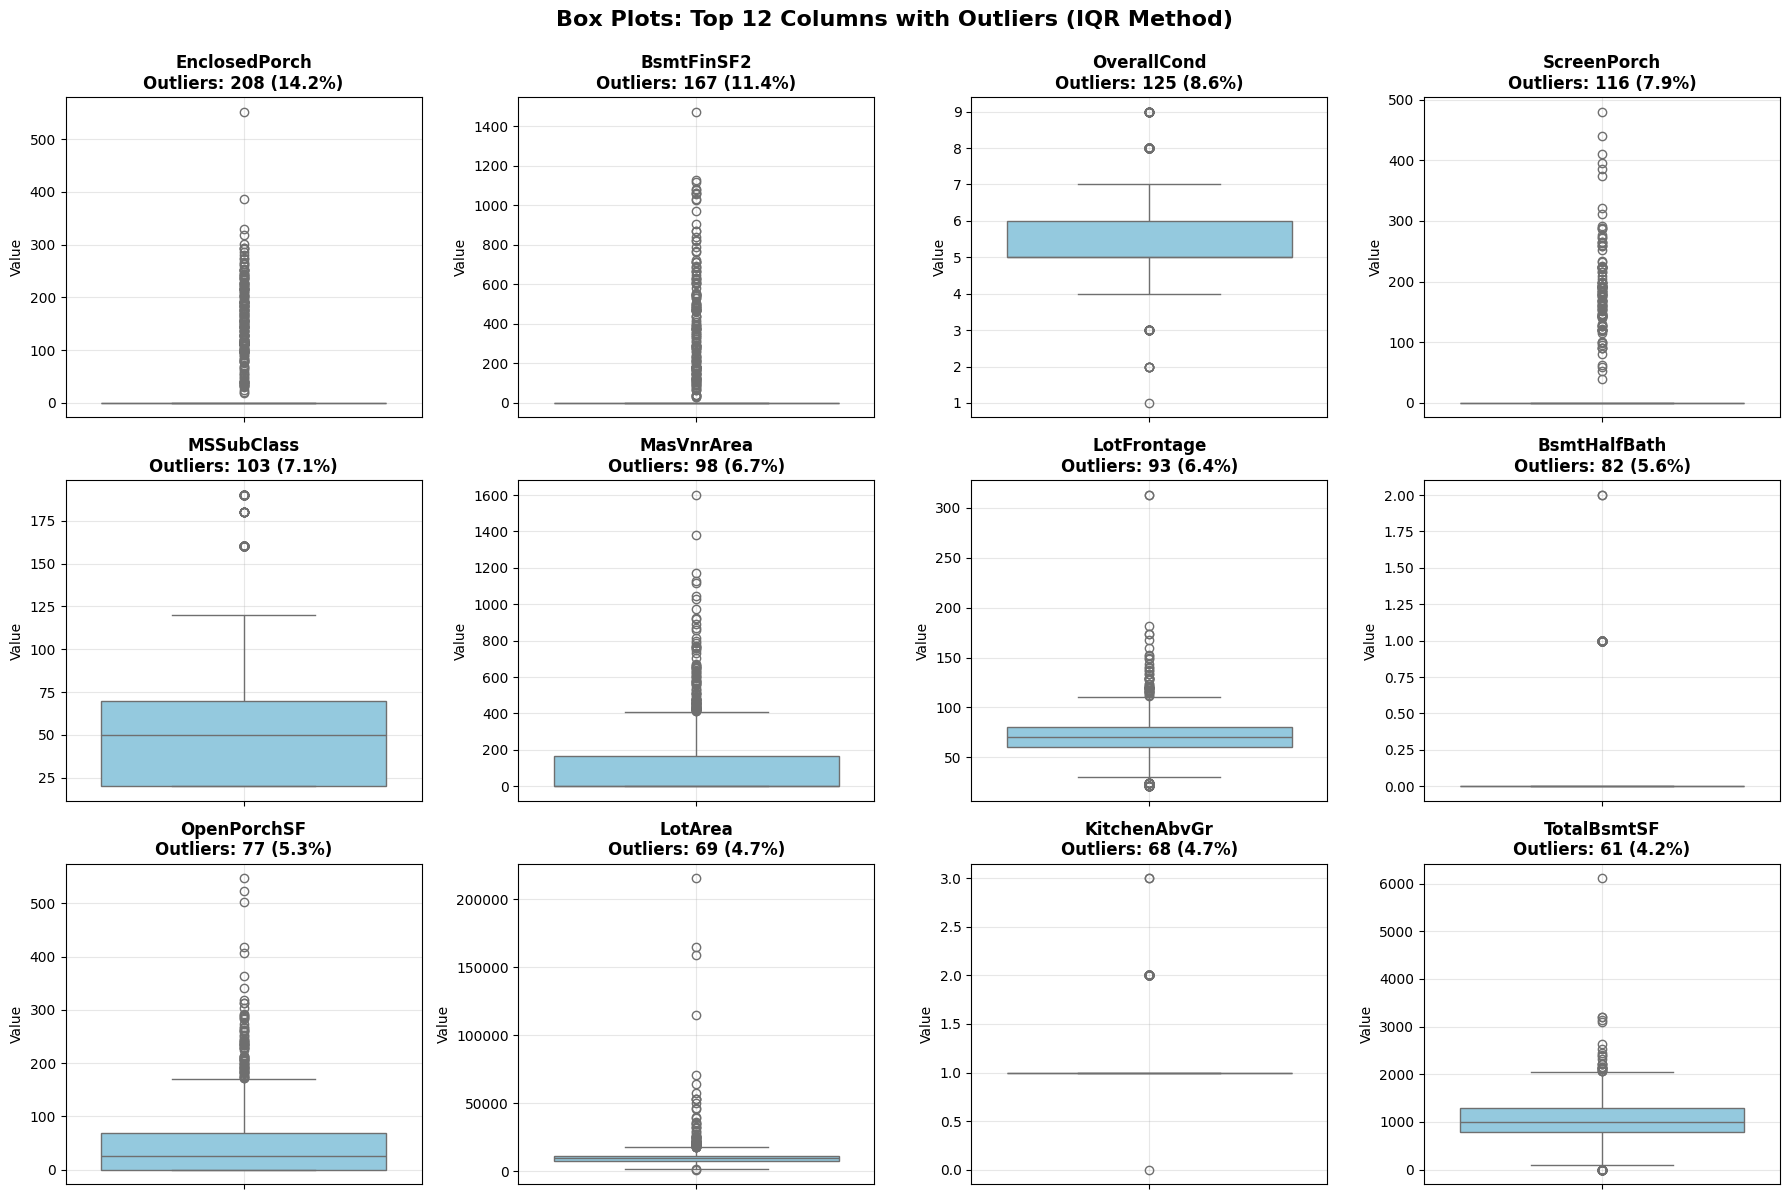

In [15]:
# Get top 12 columns with most outliers
top_outlier_cols = sorted(outliers_iqr.items(), key=lambda x: x[1]['count'], reverse=True)[:12]
top_cols = [col for col, _ in top_outlier_cols]

# Create box plots
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(top_cols):
    sns.boxplot(y=df[col], ax=axes[idx], color='skyblue')
    outlier_count = outliers_iqr[col]['count']
    outlier_pct = outliers_iqr[col]['percentage']
    
    axes[idx].set_title(f"{col}\nOutliers: {outlier_count} ({outlier_pct:.1f}%)", fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle("Box Plots: Top 12 Columns with Outliers (IQR Method)", 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


## Detailed Analysis: Target Variable (SalePrice)

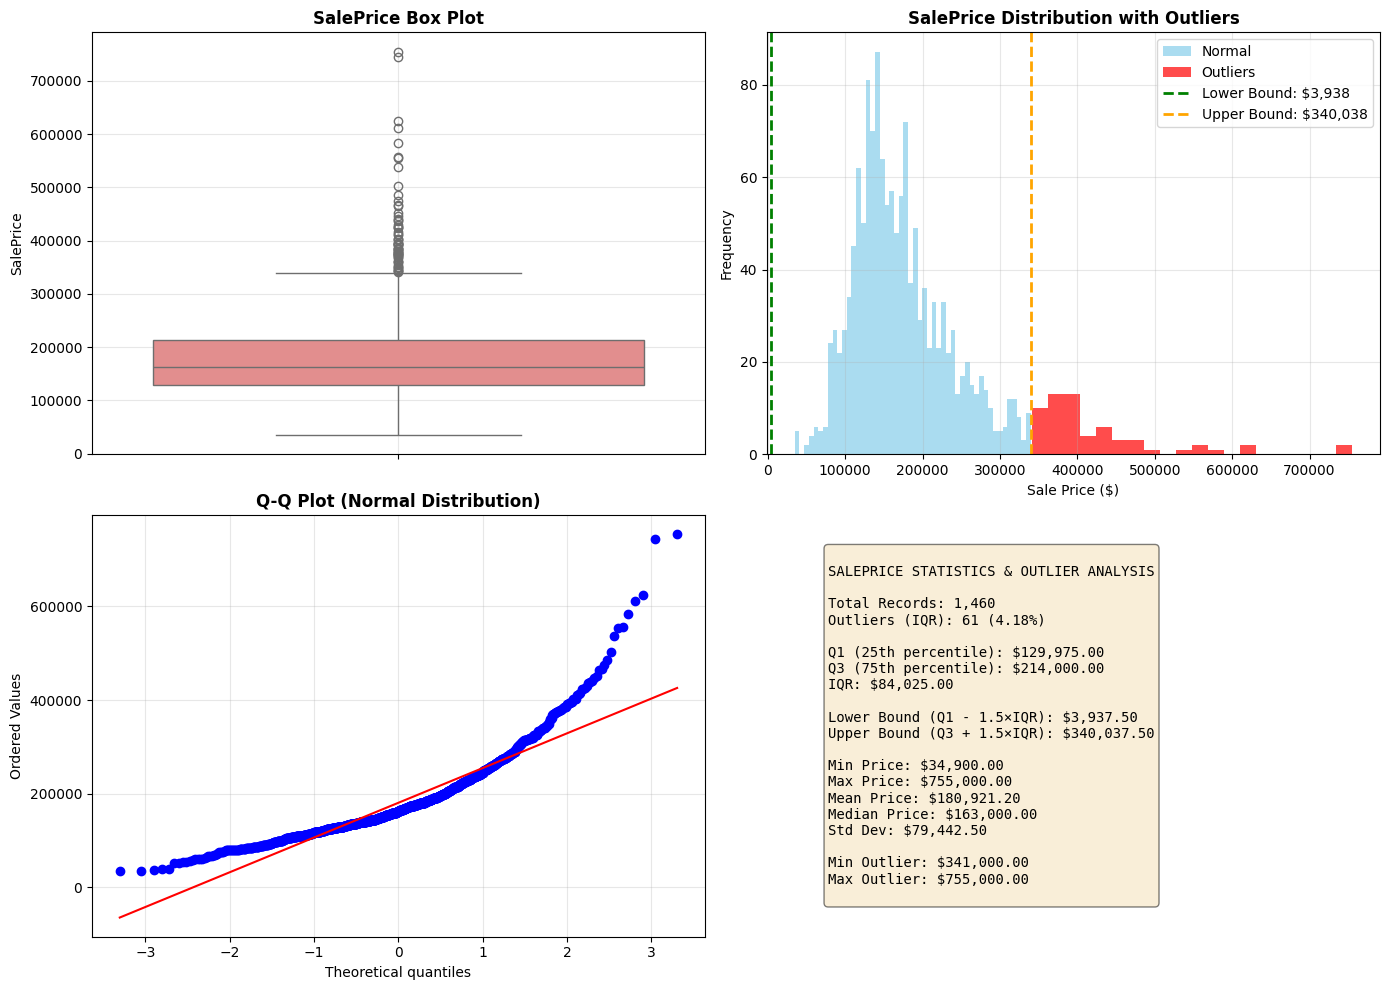


SALEPRICE STATISTICS & OUTLIER ANALYSIS

Total Records: 1,460
Outliers (IQR): 61 (4.18%)

Q1 (25th percentile): $129,975.00
Q3 (75th percentile): $214,000.00
IQR: $84,025.00

Lower Bound (Q1 - 1.5×IQR): $3,937.50
Upper Bound (Q3 + 1.5×IQR): $340,037.50

Min Price: $34,900.00
Max Price: $755,000.00
Mean Price: $180,921.20
Median Price: $163,000.00
Std Dev: $79,442.50

Min Outlier: $341,000.00
Max Outlier: $755,000.00



In [16]:
# Detailed analysis of SalePrice outliers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Box plot
sns.boxplot(y=df['SalePrice'], ax=axes[0, 0], color='lightcoral')
axes[0, 0].set_title('SalePrice Box Plot', fontweight='bold', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribution with outliers highlighted
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df['SalePrice'] < lower_bound) | (df['SalePrice'] > upper_bound)
axes[0, 1].hist(df.loc[~outlier_mask, 'SalePrice'], bins=50, alpha=0.7, label='Normal', color='skyblue')
axes[0, 1].hist(df.loc[outlier_mask, 'SalePrice'], bins=20, alpha=0.7, label='Outliers', color='red')
axes[0, 1].axvline(lower_bound, color='green', linestyle='--', linewidth=2, label=f'Lower Bound: ${lower_bound:,.0f}')
axes[0, 1].axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Bound: ${upper_bound:,.0f}')
axes[0, 1].set_title('SalePrice Distribution with Outliers', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Sale Price ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q Plot
from scipy.stats import probplot
probplot(df['SalePrice'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normal Distribution)', fontweight='bold', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# 4. Statistics table
stats_text = f"""
SALEPRICE STATISTICS & OUTLIER ANALYSIS

Total Records: {len(df):,}
Outliers (IQR): {outlier_mask.sum()} ({(outlier_mask.sum()/len(df)*100):.2f}%)

Q1 (25th percentile): ${Q1:,.2f}
Q3 (75th percentile): ${Q3:,.2f}
IQR: ${IQR:,.2f}

Lower Bound (Q1 - 1.5×IQR): ${lower_bound:,.2f}
Upper Bound (Q3 + 1.5×IQR): ${upper_bound:,.2f}

Min Price: ${df['SalePrice'].min():,.2f}
Max Price: ${df['SalePrice'].max():,.2f}
Mean Price: ${df['SalePrice'].mean():,.2f}
Median Price: ${df['SalePrice'].median():,.2f}
Std Dev: ${df['SalePrice'].std():,.2f}

Min Outlier: ${df.loc[outlier_mask, 'SalePrice'].min():,.2f}
Max Outlier: ${df.loc[outlier_mask, 'SalePrice'].max():,.2f}
"""

axes[1, 1].text(0.1, 0.5, stats_text, fontfamily='monospace', fontsize=10,
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print(stats_text)


## Visualizing Highly Skewed Distributions

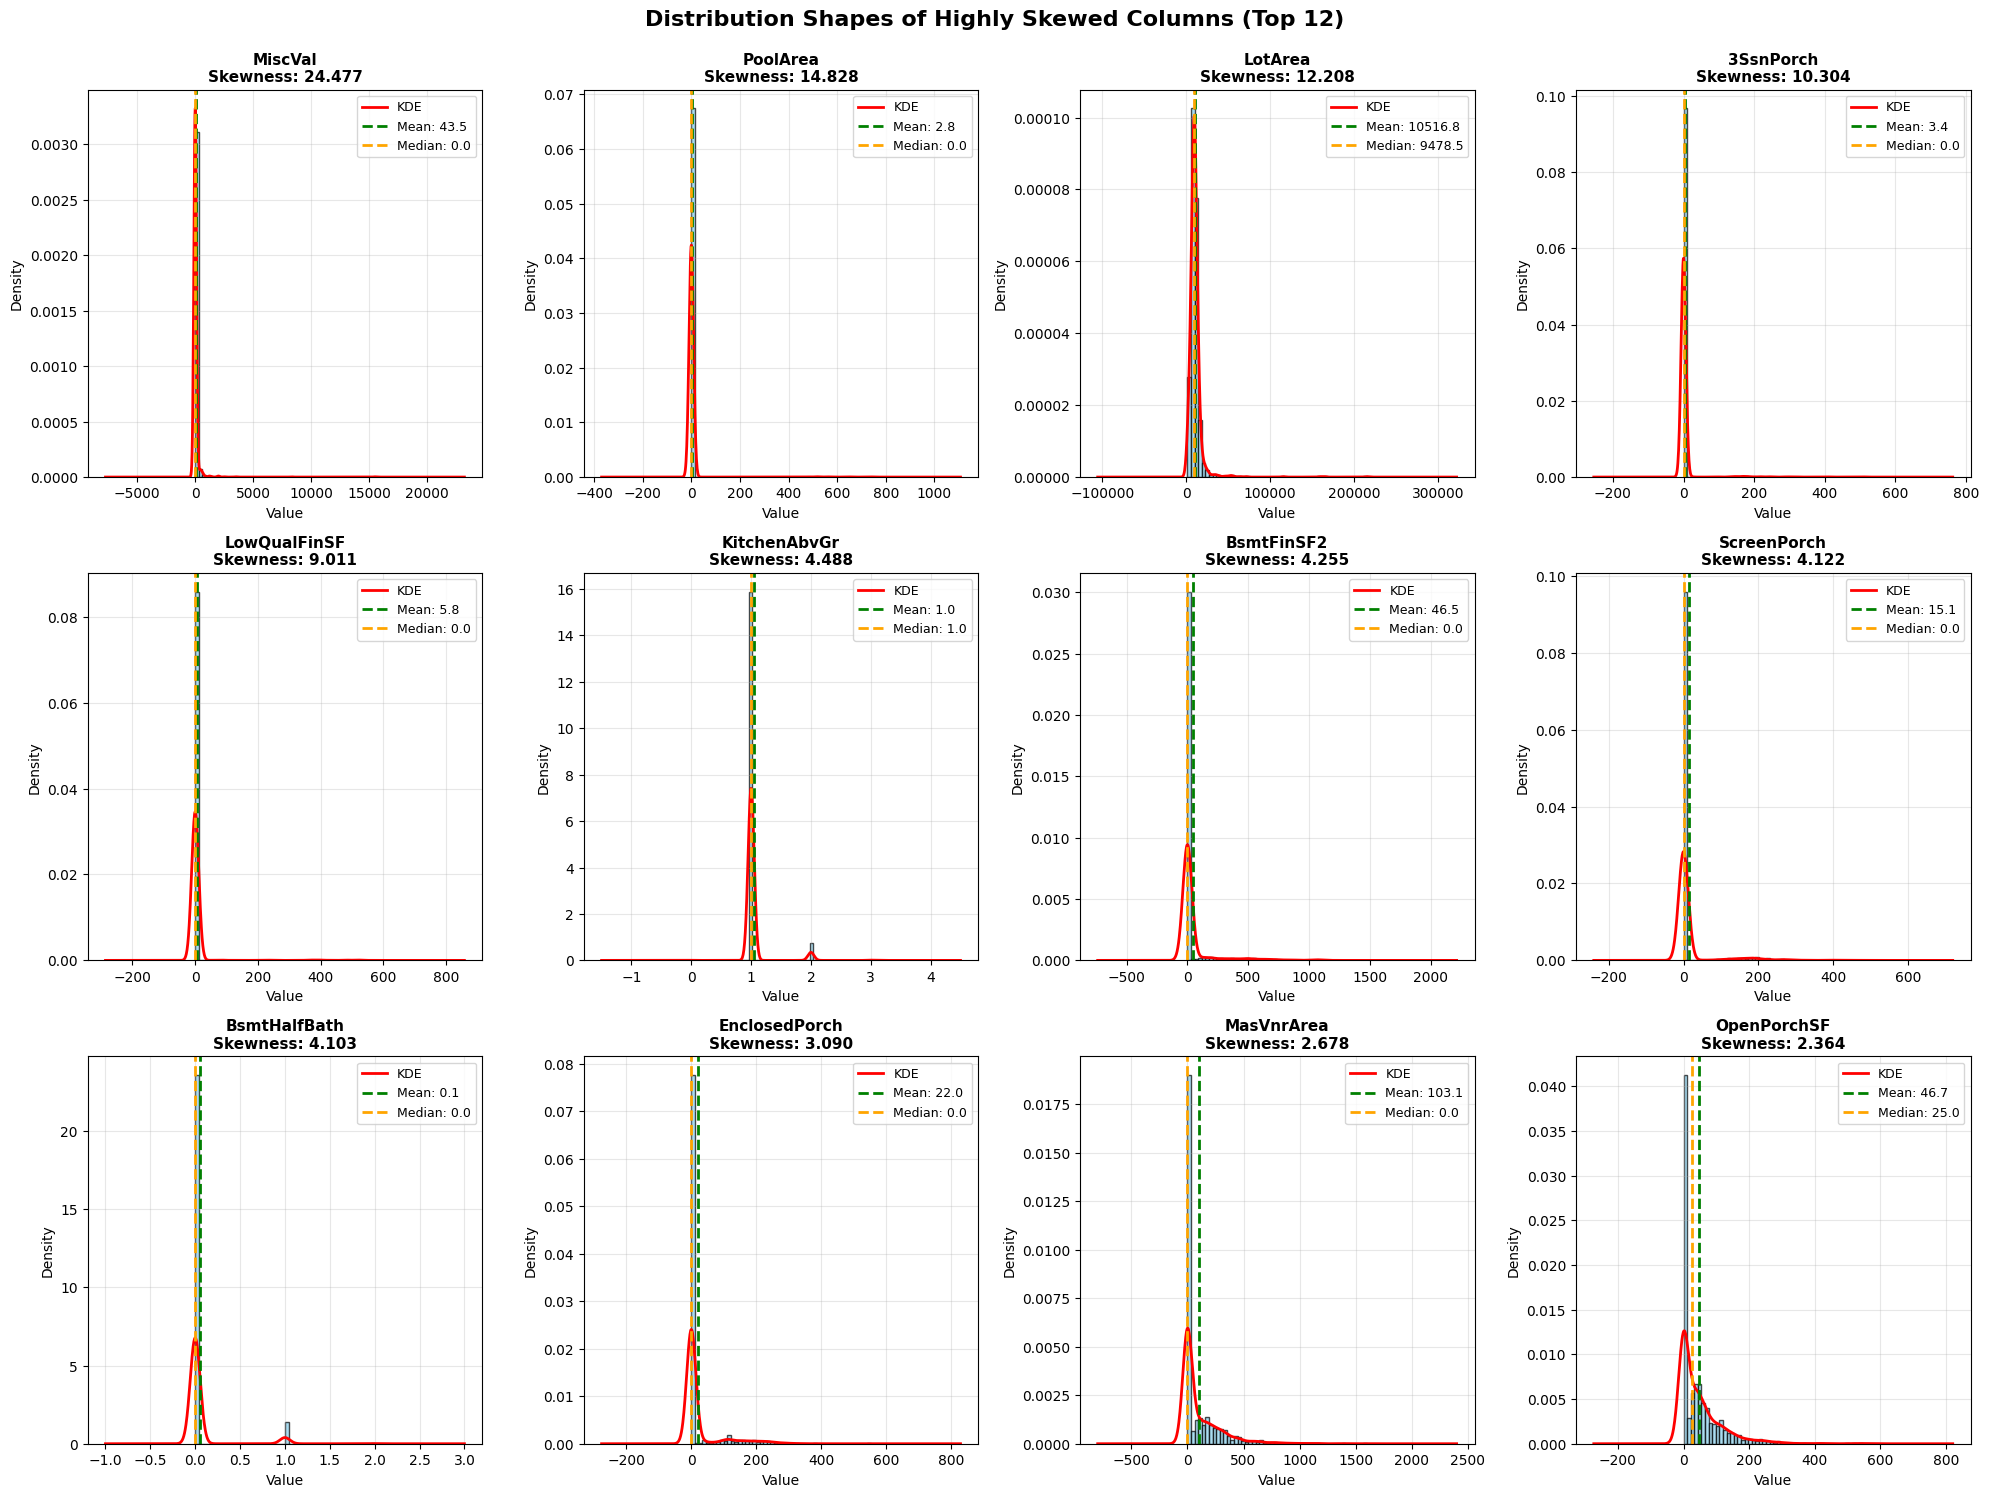

In [18]:
# Get top 12 highly skewed columns
skewed_cols = dist_df.nlargest(12, 'Skewness', keep='all')['Column'].tolist()

if len(skewed_cols) > 0:
    # Create visualizations
    n_cols = min(len(skewed_cols), 12)
    n_rows = (n_cols + 3) // 4
    
    fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5*n_rows))
    axes = axes.flatten() if n_cols > 1 else [axes]
    
    for idx, col in enumerate(skewed_cols[:12]):
        ax = axes[idx]
        
        # Get skewness value
        skew_val = df[col].skew()
        
        # Create histogram with KDE
        ax.hist(df[col], bins=50, alpha=0.7, color='skyblue', edgecolor='black', density=True)
        df[col].plot(kind='kde', ax=ax, color='red', linewidth=2, label='KDE')
        
        # Add vertical lines for mean and median
        mean_val = df[col].mean()
        median_val = df[col].median()
        ax.axvline(mean_val, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
        ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
        
        ax.set_title(f'{col}\nSkewness: {skew_val:.3f}', fontweight='bold', fontsize=11)
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(skewed_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Distribution Shapes of Highly Skewed Columns (Top 12)', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
else:
    print("No highly skewed columns to visualize.")


#### Conclusion
   This is a NATURALLY SKEWED dataset - EXPECTED for housing data:
   
   1. Right-skew is normal (market has outlier luxury properties)
   2. Heavy tails are realistic (few extremely large/expensive homes)
   3. Concentration patterns make sense (common features, rare special features)
   4. Spikes correspond to logical categories (no garage, no basement, etc.)